# Task 1 — EDA on Retail Sales Data

**Goal:** Explore the Superstore retail sales dataset to find patterns in sales, customers and products, and come up with some business recommendations.

Dataset: Superstore Sales (order-level retail data, ~8400 rows). Source: Kaggle "Sample Superstore" style dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("superstore.csv", encoding="latin1")
df.shape

(8399, 21)

## 1. First look at the data

In [2]:
df.head()

,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,...,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,10/13/2010,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,...,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010
1,49,293,10/1/2012,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012
2,50,293,10/1/2012,High,27,244.5700,0.01,Regular Air,46.71,8.69,...,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D¨ Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012
3,80,483,7/10/2011,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,...,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,7/12/2011
4,85,515,8/28/2010,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,...,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Row ID                8399 non-null   int64  
 1   Order ID              8399 non-null   int64  
 2   Order Date            8399 non-null   str    
 3   Order Priority        8399 non-null   str    
 4   Order Quantity        8399 non-null   int64  
 5   Sales                 8399 non-null   float64
 6   Discount              8399 non-null   float64
 7   Ship Mode             8399 non-null   str    
 8   Profit                8399 non-null   float64
 9   Unit Price            8399 non-null   float64
 10  Shipping Cost         8399 non-null   float64
 11  Customer Name         8399 non-null   str    
 12  Province              8399 non-null   str    
 13  Region                8399 non-null   str    
 14  Customer Segment      8399 non-null   str    
 15  Product Category      8399 non-n

In [4]:
df.isnull().sum()

Row ID                   0
Order ID                 0
Order Date               0
Order Priority           0
Order Quantity           0
Sales                    0
Discount                 0
Ship Mode                0
Profit                   0
Unit Price               0
Shipping Cost            0
Customer Name            0
Province                 0
Region                   0
Customer Segment         0
Product Category         0
Product Sub-Category     0
Product Name             0
Product Container        0
Product Base Margin     63
Ship Date                0
dtype: int64

**Observation:** Dataset has 8399 rows and 21 columns. Only `Product Base Margin` has missing values (about 68 rows), rest of the columns are complete. Order Date and Ship Date are stored as text (object) right now, so I'll convert them to datetime before doing any time-based analysis.

In [5]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df["Order Date"].min(), df["Order Date"].max()

(Timestamp('2009-01-01 00:00:00'), Timestamp('2012-12-30 00:00:00'))

## 2. Descriptive statistics

In [6]:
df[["Sales", "Profit", "Discount", "Order Quantity", "Unit Price", "Shipping Cost"]].describe()

,Sales,Profit,Discount,Order Quantity,Unit Price,Shipping Cost
count,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000
mean,1775.878179,181.184424,0.049671,25.571735,89.346259,12.838557
std,3585.050525,1196.653371,0.031823,14.481071,290.354383,17.264052
min,2.240000,-14140.700000,0.000000,1.000000,0.990000,0.490000
25%,143.195000,-83.315000,0.020000,13.000000,6.480000,3.300000
50%,449.420000,-1.500000,0.050000,26.000000,20.990000,6.070000
75%,1709.320000,162.750000,0.080000,38.000000,85.990000,13.990000
max,89061.050000,27220.690000,0.250000,50.000000,6783.020000,164.730000


**Observation:** Average order sale is around a few hundred dollars but the max value is way higher than the mean, so sales are right-skewed (a small number of big orders pull the average up). Profit actually has negative values in some rows, meaning some orders are sold at a loss (probably because of high discounts).

## 3. Time series analysis — monthly & quarterly sales trend

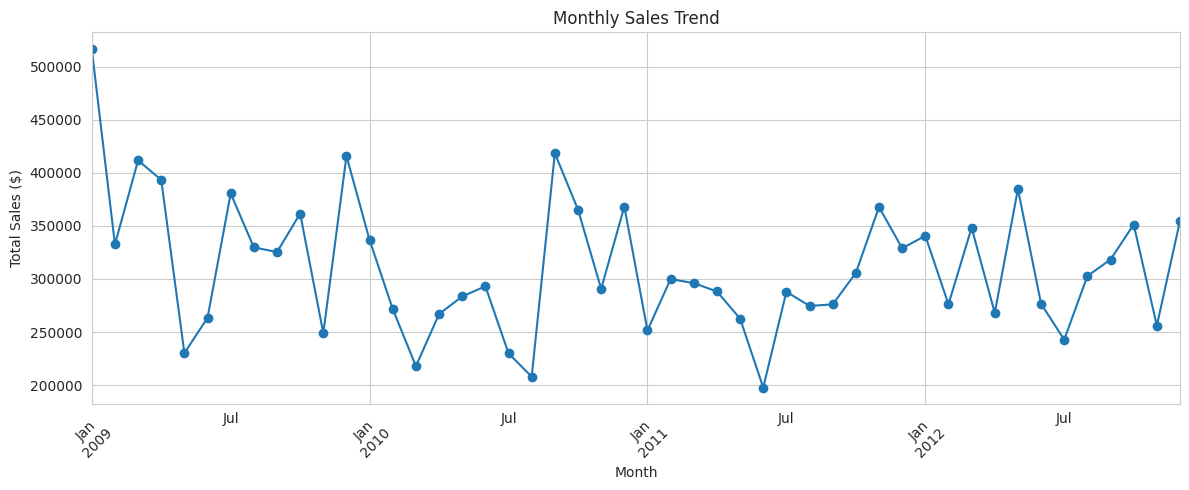

In [7]:
df["OrderMonth"] = df["Order Date"].dt.to_period("M")
monthly_sales = df.groupby("OrderMonth")["Sales"].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_sales.png")
plt.show()

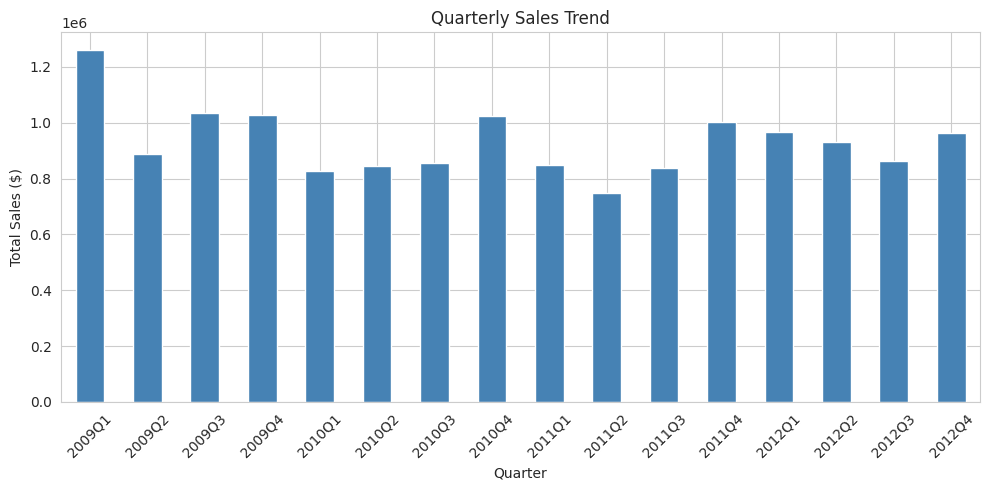

In [8]:
df["OrderQuarter"] = df["Order Date"].dt.to_period("Q")
quarterly_sales = df.groupby("OrderQuarter")["Sales"].sum()

plt.figure(figsize=(10, 5))
quarterly_sales.plot(kind="bar", color="steelblue")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("quarterly_sales.png")
plt.show()

**Observation:** Sales are not flat through the year — there's a clear seasonal bump toward the last quarter of every year (Q4), which is expected because of the holiday shopping season. Some months are quite low compared to others, which could guide inventory/staffing decisions.

## 4. Customer / order priority breakdown

This dataset doesn't have individual age/gender columns (it's order-level, business-focused), so instead I looked at **Customer Segment** and **Order Priority**, which serve a similar "who is buying and how" role.

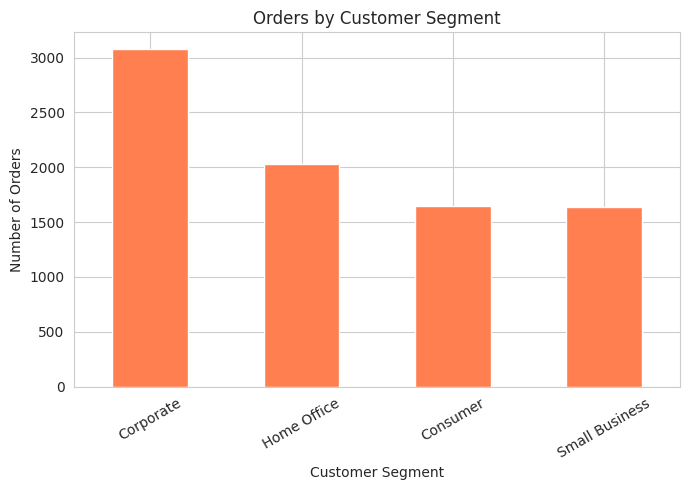

In [9]:
plt.figure(figsize=(7, 5))
df["Customer Segment"].value_counts().plot(kind="bar", color="coral")
plt.title("Orders by Customer Segment")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("customer_segment.png")
plt.show()

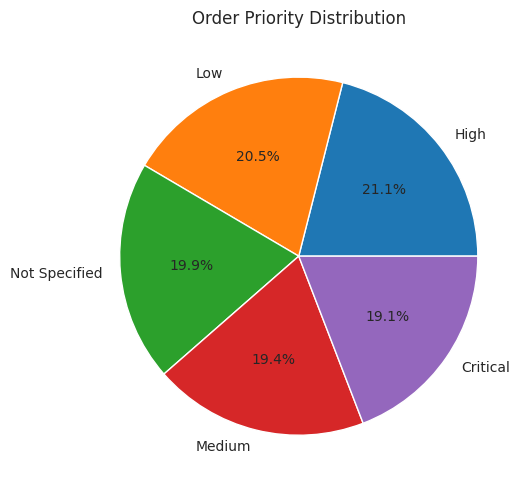

In [10]:
plt.figure(figsize=(7, 5))
df["Order Priority"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Order Priority Distribution")
plt.ylabel("")
plt.tight_layout()
plt.savefig("order_priority.png")
plt.show()

**Observation:** "Consumer" is the biggest customer segment by number of orders, followed by Corporate and then Home Office / Small Business. Most orders are "Medium" or "High" priority, "Critical" priority orders are a small slice — those are probably rush/urgent shipments and could be checked for extra shipping cost impact.

## 5. Product analysis

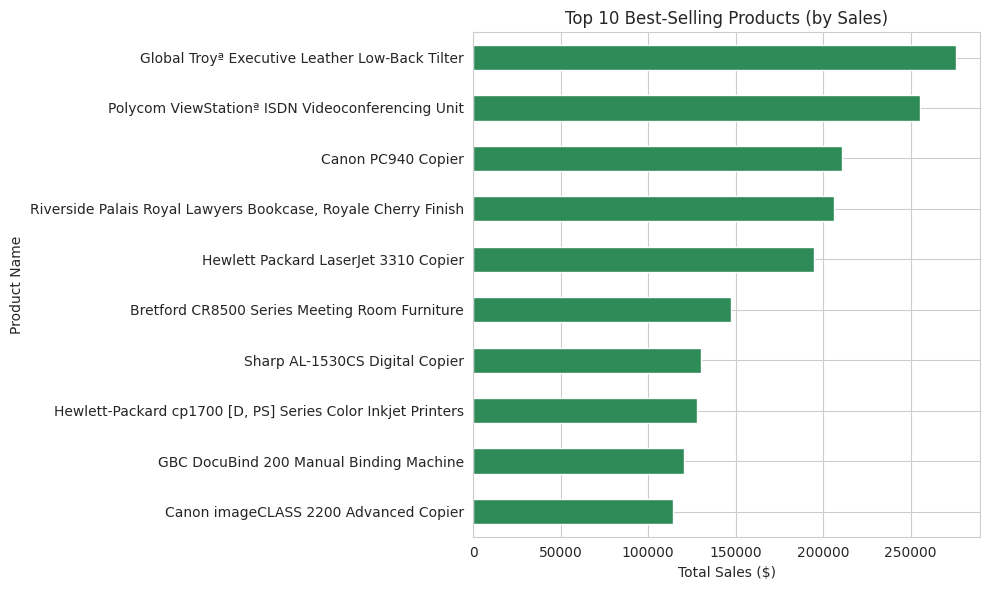

In [11]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_products.plot(kind="barh", color="seagreen")
plt.title("Top 10 Best-Selling Products (by Sales)")
plt.xlabel("Total Sales ($)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top_products.png")
plt.show()

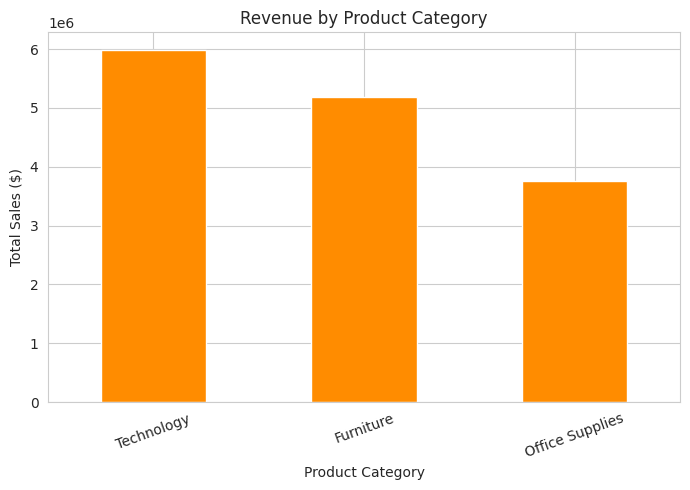

In [12]:
category_sales = df.groupby("Product Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
category_sales.plot(kind="bar", color="darkorange")
plt.title("Revenue by Product Category")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("category_sales.png")
plt.show()

**Observation:** Technology and Furniture categories bring in the most revenue per order (higher unit prices), while Office Supplies has more orders but lower revenue per order. The top 10 product list is dominated by big-ticket items like office furniture and machines.

## 6. Correlation heatmap

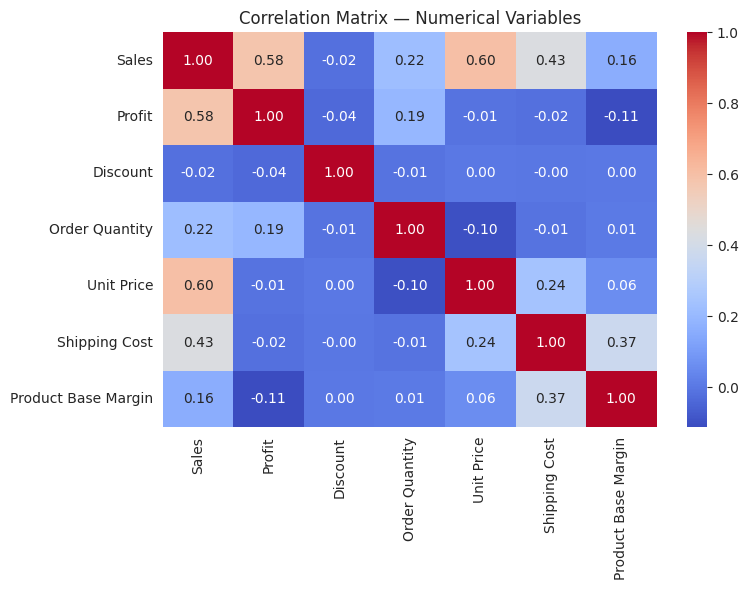

In [13]:
num_cols = ["Sales", "Profit", "Discount", "Order Quantity", "Unit Price", "Shipping Cost", "Product Base Margin"]
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix — Numerical Variables")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()

**Observation:** Sales and Shipping Cost are positively correlated (bigger orders cost more to ship, makes sense). Discount has a weak negative relationship with Profit — higher discounts tend to eat into profit, though it's not a very strong correlation on its own.

## 7. Extra insight — Discount vs Profit

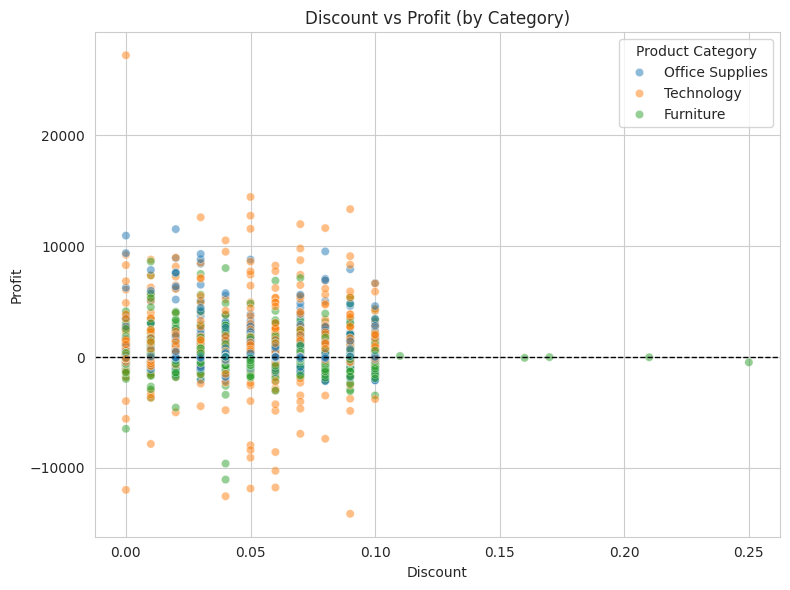

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Discount", y="Profit", hue="Product Category", alpha=0.5)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Discount vs Profit (by Category)")
plt.tight_layout()
plt.savefig("discount_vs_profit.png")
plt.show()

**Observation (non-obvious insight):** Once discounts go above roughly 20-30%, a big chunk of orders start showing negative profit (below the dashed line), and this pattern is worse for some categories like Furniture. This suggests the company might be over-discounting certain product lines to the point where they lose money on the sale.

## 8. Conclusion — Business Recommendations

Based on the analysis above:

1. **Watch high-discount orders closely.** Orders with discounts above ~25-30% frequently turn into losses, especially in Furniture. A discount cap or manager approval above this threshold could protect margins.
2. **Plan inventory/staffing around Q4.** Sales consistently spike in the last quarter, so stock levels, staffing and marketing spend should ramp up ahead of that season instead of reacting to it.
3. **Double down on Technology & Furniture for revenue, but improve Office Supplies conversion.** Office Supplies gets a high number of orders but comparatively low revenue per order — bundling or upselling accessories alongside these orders could raise the average order value.